In [134]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/cleaned_listings.csv")
print(df.shape)
df.head()

(23223, 26)


,locality,property_type,subtype,price_eur,type_of_sale,num_rooms,living_area_m2,fully_equipped_kitchen,furnished,terrace,...,state_of_building,num_bathrooms,dist_train_km,dist_bus_km,price_per_m2,postal_code,region,outlier_flag,avg_price_locality,building_state_encoded
0,3190 Boortmeerbeek,House,Residence,498000.0,for sale,4.0,171.0,0.0,0.0,1.0,...,Normal,2.0,1.5,0.750,2912.28,3190,Flanders,False,466166.7,5.0
1,2350 Vosselaar,House,Residence,285000.0,for sale,2.0,128.0,0.0,0.0,0.0,...,Normal,1.0,3.7,0.591,2226.56,2350,Flanders,False,403642.9,5.0
2,4460 Grâce-Hollogne,House,Residence,119000.0,for sale,2.0,95.0,0.0,0.0,0.0,...,To renovate,1.0,4.3,0.321,1252.63,4460,Wallonia,False,262344.8,3.0
3,1420 Braine-l'Alleud,House,Residence,565000.0,for sale,4.0,175.0,0.0,NaN,1.0,...,Excellent,NaN,1.8,1.300,3228.57,1420,Wallonia,False,636935.7,8.0
4,1200 Sint-Lambrechts-Woluwe,House,Residence,560000.0,for sale,5.0,213.0,0.0,0.0,1.0,...,To be renovated,3.0,2.9,0.242,2629.11,1200,Brussels,False,584235.9,4.0


In [136]:
df['price_eur'].quantile(0.995)
upper = df["price_eur"].quantile(0.995)
df = df[df["price_eur"] <= upper]

In [137]:
# Fill missing land values for appartements with 0

df.loc[df["property_type"] == "Apartment", "land_surface_m2"] = df.loc[
    df["property_type"] == "Apartment", "land_surface_m2"
].fillna(0)

In [138]:
# asign first 2 digit to each province
df["province_code"] = df["postal_code"] // 100

In [139]:
"""# Drop properties where number of bathrooms is bigger than number of rooms
df[df['num_bathrooms'] > df['num_rooms'] + 2].shape[0] # 39
df = df[df["num_bathrooms"] <= df["num_rooms"] + 2]"""

'# Drop properties where number of bathrooms is bigger than number of rooms\ndf[df[\'num_bathrooms\'] > df[\'num_rooms\'] + 2].shape[0] # 39\ndf = df[df["num_bathrooms"] <= df["num_rooms"] + 2]'

In [140]:
print(df.groupby("province_code")["region"].first().sort_index())

province_code
10    Brussels
11    Brussels
12    Brussels
13    Wallonia
14    Wallonia
        ...   
95    Flanders
96    Flanders
97    Flanders
98    Flanders
99    Flanders
Name: region, Length: 80, dtype: object


In [ ]:
drop_cols = [
    "locality",                 # Cant use
    "type_of_sale",             # Only one vale "for_sale"
    "furnished",                # 34% missing and only 2.8% are furnished
    "garden_area_m2",           # Kept binary instead (1 & 0) to many missing values
    "price_per_m2",             # Data leakage (calculated from price)
    "outlier_flag",             # Derived from price
    "avg_price_locality",       # Data leakage (calculated from price)
    "state_of_building",        # Repalced by encoded building state
    "terrace_area_m2",          # Kept binary
    "postal_code",              # onehot enoder would create too many columns. Use target encoding ?
    "region",                   # Removed after creating province_code
]

feature_cols = [
    "property_type",
    "subtype",
    "num_rooms",
    "living_area_m2",
    "terrace",
    "garden",
    "land_surface_m2",
    "num_facades",
    
    "num_bathrooms",
    "building_state_encoded",
    "swimming_pool",
    "fully_equipped_kitchen",
    "dist_train_km",
    "dist_bus_km",
    "province_code"
]

target = "price_eur"

In [142]:
X = df[feature_cols]
y = df[target]

print(X.shape)
print(y.shape)

(23106, 15)
(23106,)


In [143]:
# Splitting feature_cols in two lists
numeric_features = [
    "num_rooms",
    "living_area_m2",
    "terrace",
    "garden",
    "land_surface_m2",
    "num_facades",
    "num_bathrooms",
    "building_state_encoded",
    "swimming_pool",
    "fully_equipped_kitchen",
    "dist_train_km",
    "dist_bus_km",
    "province_code",
]

categorical_features = [
    "property_type",
    "subtype",
]

In [144]:
from sklearn.model_selection import train_test_split

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

print(X_train.shape)
print(X_test.shape)

(18484, 15)
(4622, 15)


#### Building the pipeline


In [145]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score

##### Building two sub pipelines.
- numeric_transformer
- categorical_transformer
##### Then we combine them with ColumnTransformer

In [146]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())]
)

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [147]:
# Completing the full pipeline
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])


In [148]:
preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [149]:
from sklearn.linear_model import LinearRegression

pipeline_lr = Pipeline(
    steps=[("preprocessor", preprocessor), ("model", LinearRegression())]
)

# Fit the pipeline
pipeline_lr.fit(X_train, y_train)

y_pred = pipeline_lr.predict(X_test)

r2 = r2_score(y_test, y_pred)

print(f"R²:   {r2:.4f}")

R²:   0.5599


In [ ]:
"""import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([0, 3000000], [0, 3000000], "r--")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()"""

In [ ]:
from sklearn.ensemble import RandomForestRegressor

pipeline_rf = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(n_estimators=100, random_state=0, n_jobs=-1)),
    ]
)

pipeline_rf.fit(X_train, y_train)
y_pred_rf = pipeline_rf.predict(X_test)


print(f"R²:   {r2_score(y_test, y_pred_rf):.4f}")

R²:   0.7772


In [152]:
pipeline_rf

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [153]:
from xgboost import XGBRegressor

pipeline_xgb = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBRegressor(
                n_estimators=500,
                learning_rate=0.05,
                max_depth=6,
                random_state=0,
                n_jobs=-1,
            ),
        ),
    ]
)

pipeline_xgb.fit(X_train, y_train)
y_pred_xgb2 = pipeline_xgb.predict(X_test)


print(f"R²:   {r2_score(y_test, y_pred_xgb2):.4f}")

R²:   0.7860


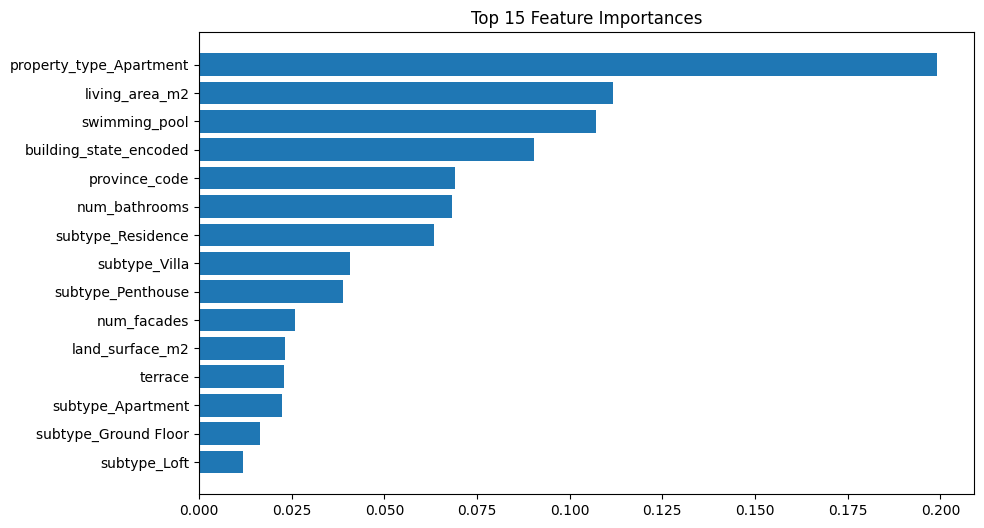

In [155]:
import matplotlib.pyplot as plt

# Get feature names after preprocessing
cat_features = (
    pipeline_xgb.named_steps["preprocessor"]
    .named_transformers_["cat"]["encoder"]
    .get_feature_names_out(categorical_features)
)

all_features = numeric_features + list(cat_features)

# Get importances
importances = pipeline_xgb.named_steps["model"].feature_importances_

# Plot top 15
indices = np.argsort(importances)[-15:]
plt.figure(figsize=(10, 6))
plt.barh([all_features[i] for i in indices], importances[indices])
plt.title("Top 15 Feature Importances")
plt.show()

## What we did?
#### Step 1: We divided the dataset in drop_cols and feature_cols
After that we assigned feature_cols to X and target(price_eur) to y.
We also splitted in numeric and categorical because different features need different preprocessing. Numeric we impute with median and than scale / Categorical we impute with most frequent and then one hot encode
#### Step 2: We splitted the dataset Train/Test before building the pipeline
we used a 80/20 split and random state 0 to get the same results every run
#### Step 3: Pipeline (median and scaling are learned only from X_train and not from the X_test)
- Imputed missing numerical with median then scale
- Imputed missing categorical with most frequent and then one hot encode
- Combined both transformers
- Build the final pipeline where we assign also the model that we can change for other models to compare
#### Step 4: Train and evaluate the model
- Linear Regression results = 0.5869
- Random Forest     results = 0.7257
- XGBoost           results = 0.7442
-----------------------------------------
##### After creating province_col
- Linear Regression results = 0.5921
- Random Forest     results = 0.7583
- XGBoost           results = 0.7962
----------------------------------------
##### After droping region col
- Linear Regression results = 0.5539
- Random Forest     results = 0.7646
- XGBoost           results = 0.7935

Linear regression suffers the most after droping the region from the dataset. Tree models handle better redundacy better. Add it again? Not much difference for tree models compared to LR

----------------------------------------
##### After droping properties over 1M
- Linear Regression results = 0.4943
- Random Forest     results = 0.7279
- XGBoost           results = 0.7440

This removed 718 preporties. 52% of them in Brussels. Brussels location is one of our most important feature and by removing half of most expensive properties, the model had less data to train and learn price pattern. We will keep the prices over 1M even though they might add noise to our model.

----------------------------------------
##### After droping 0.5 of properties that are over 99.5% (quantile)
- Linear Regression results = 0.5599
- Random Forest     results = 0.7740
- XGBoost           results = 0.7860
----------------------------------------
##### After droping properties where number of bathrooms is bigger than number of rooms + 2
- Linear Regression results = 0.5819
- Random Forest     results = 0.7516
- XGBoost           results = 0.7847

